# 02 — Exploratory Data Analysis on Yelp Reviews

This notebook performs EDA on the raw Yelp reviews that the previous notebooks staged in S3 and registered with Athena. All charts produced here are stored alongside the notebook so they appear directly in GitHub when the `.ipynb` is opened.

The EDA answers the standard questions for an MLOps text-classification project:

1. How many reviews are available?
2. What does the star rating distribution look like?
3. After dropping neutral (3-star) reviews and labeling 1–2 stars as `negative` and 4–5 stars as `positive`, what is the class balance?
4. How long are reviews (word count distribution)?
5. Are there missing or empty review-text fields that need to be excluded?
6. What words are most common in positive vs negative reviews?

In [14]:
!pip install --disable-pip-version-check --quiet awswrangler PyAthena matplotlib seaborn

In [15]:
import re
from collections import Counter

import boto3
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from pyathena import connect

from plot_style import (
    apply_style,
    PURPLE_PRIMARY,
    PURPLE_DARK,
    PURPLE_LIGHT,
    PURPLE_SENTIMENT,
    purple_sequential,
)

%store -r bucket
%store -r region
%store -r database_name
%store -r s3_staging_dir
%store -r parquet_table_name

apply_style()

conn = connect(region_name=region, s3_staging_dir=s3_staging_dir)
table = f"{database_name}.{parquet_table_name}"
print("Querying Athena table:", table)

Querying Athena table:

 yelp_db.reviews_parquet


## 1. Total review count

In [16]:
total_df = pd.read_sql(f"SELECT COUNT(*) AS total_reviews FROM {table}", conn)
total_reviews = int(total_df["total_reviews"].iloc[0])
print(f"Total reviews in {table}: {total_reviews:,}")

/tmp/ipykernel_667/3075519244.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  total_df = pd.read_sql(f"SELECT COUNT(*) AS total_reviews FROM {table}", conn)


Total reviews in yelp_db.reviews_parquet: 299,991


## 2. Star rating distribution

In [17]:
stars_df = pd.read_sql(
    f"SELECT stars, COUNT(*) AS review_count FROM {table} GROUP BY stars ORDER BY stars",
    conn,
)
stars_df

/tmp/ipykernel_667/1828416532.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  stars_df = pd.read_sql(


,stars,review_count
0,1.0,33402
1,2.0,24158
2,3.0,33986
3,4.0,75163
4,5.0,133282


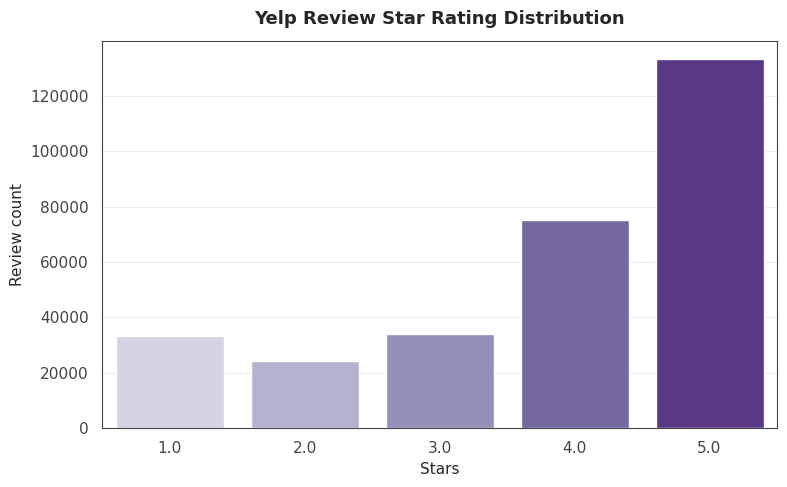

In [18]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(
    data=stars_df,
    x="stars",
    y="review_count",
    hue="stars",
    palette=purple_sequential(len(stars_df)),
    legend=False,
    ax=ax,
)
ax.set_title("Yelp Review Star Rating Distribution")
ax.set_xlabel("Stars")
ax.set_ylabel("Review count")
plt.tight_layout()
plt.savefig("../reports/eda_star_distribution.png", dpi=150)
plt.show()

## 3. Sentiment class balance (after dropping 3-star reviews)

In [19]:
sentiment_df = pd.read_sql(
    f"""
    SELECT
        CASE WHEN stars >= 4 THEN 'positive' WHEN stars <= 2 THEN 'negative' END AS sentiment,
        COUNT(*) AS review_count
    FROM {table}
    WHERE stars <> 3
    GROUP BY 1
    ORDER BY 1
    """,
    conn,
)
sentiment_df["share"] = (sentiment_df["review_count"] / sentiment_df["review_count"].sum()).round(4)
sentiment_df

/tmp/ipykernel_667/1754257901.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  sentiment_df = pd.read_sql(


,sentiment,review_count,share
0,negative,57560,0.2164
1,positive,208445,0.7836


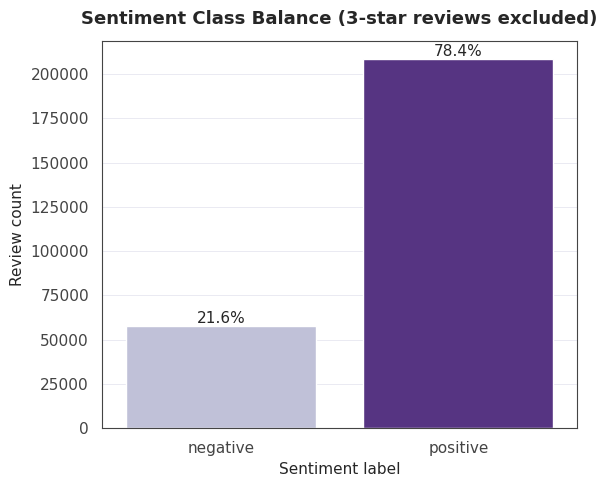

In [20]:
fig, ax = plt.subplots(figsize=(6, 5))
sns.barplot(
    data=sentiment_df,
    x="sentiment",
    y="review_count",
    hue="sentiment",
    palette=PURPLE_SENTIMENT,
    legend=False,
    ax=ax,
)
ax.set_title("Sentiment Class Balance (3-star reviews excluded)")
ax.set_xlabel("Sentiment label")
ax.set_ylabel("Review count")
for index, row in sentiment_df.iterrows():
    ax.text(index, row["review_count"], f"{row['share']:.1%}", ha="center", va="bottom")
plt.tight_layout()
plt.savefig("../reports/eda_class_balance.png", dpi=150)
plt.show()

## 4. Review length distribution

In [21]:
length_df = pd.read_sql(
    f"""
    SELECT review_char_length
    FROM {table}
    TABLESAMPLE BERNOULLI(10)
    """,
    conn,
)
length_df["review_char_length"].describe()

/tmp/ipykernel_667/3395528164.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  length_df = pd.read_sql(


count    30018.000000
mean       548.552668
std        504.859373
min         10.000000
25%        225.000000
50%        396.000000
75%        689.000000
max       4997.000000
Name: review_char_length, dtype: float64

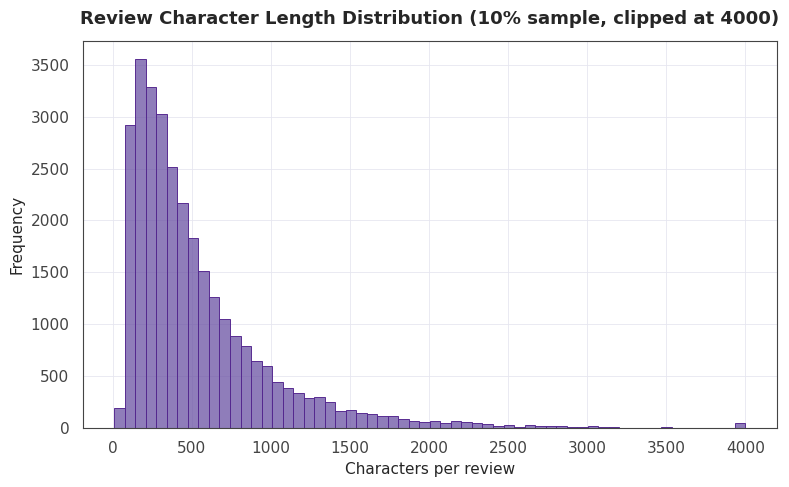

In [22]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.histplot(
    length_df.clip(upper=4000),
    x="review_char_length",
    bins=60,
    color=PURPLE_PRIMARY,
    edgecolor=PURPLE_DARK,
    ax=ax,
)
ax.set_title("Review Character Length Distribution (10% sample, clipped at 4000)")
ax.set_xlabel("Characters per review")
ax.set_ylabel("Frequency")
plt.tight_layout()
plt.savefig("../reports/eda_review_length.png", dpi=150)
plt.show()

## 5. Missing or empty review text

In [23]:
missing_df = pd.read_sql(
    f"""
    SELECT
        SUM(CASE WHEN review_text IS NULL OR TRIM(review_text) = '' THEN 1 ELSE 0 END) AS missing_text,
        SUM(CASE WHEN stars IS NULL THEN 1 ELSE 0 END) AS missing_stars
    FROM {database_name}.reviews_raw
    """,
    conn,
)
missing_df

/tmp/ipykernel_667/3445980097.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  missing_df = pd.read_sql(


,missing_text,missing_stars
0,9,0


## 6. Most common words per sentiment class

We pull a balanced sample (5,000 per class) for a lightweight word-frequency analysis. This is not the modeling step, just an EDA sanity check that the labels reflect the kind of language we expect.

In [24]:
STOPWORDS = {
    "the", "a", "an", "and", "or", "but", "to", "of", "in", "on", "at", "for", "with",
    "i", "you", "we", "they", "he", "she", "it", "is", "was", "were", "are", "be", "been",
    "have", "has", "had", "do", "did", "does", "this", "that", "my", "our", "their",
    "so", "as", "if", "not", "no", "yes", "just", "would", "could", "should", "there",
    "here", "then", "than", "its", "about", "out", "up", "from", "by", "me", "us",
}

def top_words(text_series: pd.Series, n: int = 20) -> pd.DataFrame:
    counter: Counter = Counter()
    for text in text_series:
        if not isinstance(text, str):
            continue
        for token in re.findall(r"[a-z']+", text.lower()):
            if token in STOPWORDS or len(token) < 3:
                continue
            counter[token] += 1
    return pd.DataFrame(counter.most_common(n), columns=["word", "count"])

positive_sample = pd.read_sql(
    f"SELECT review_text FROM {table} WHERE stars >= 4 LIMIT 5000", conn
)
negative_sample = pd.read_sql(
    f"SELECT review_text FROM {table} WHERE stars <= 2 LIMIT 5000", conn
)

top_positive = top_words(positive_sample["review_text"])
top_negative = top_words(negative_sample["review_text"])
display(top_positive)
display(top_negative)

/tmp/ipykernel_667/106061344.py:20: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  positive_sample = pd.read_sql(


/tmp/ipykernel_667/106061344.py:23: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  negative_sample = pd.read_sql(


,word,count
0,great,2854
1,food,2477
2,good,2458
3,place,2319
4,very,2145
5,all,1682
6,service,1427
7,time,1377
8,it's,1343
9,like,1314


,word,count
0,food,3274
1,place,2355
2,when,2268
3,all,2137
4,like,2125
5,service,2065
6,get,2054
7,one,2021
8,time,2009
9,back,1972


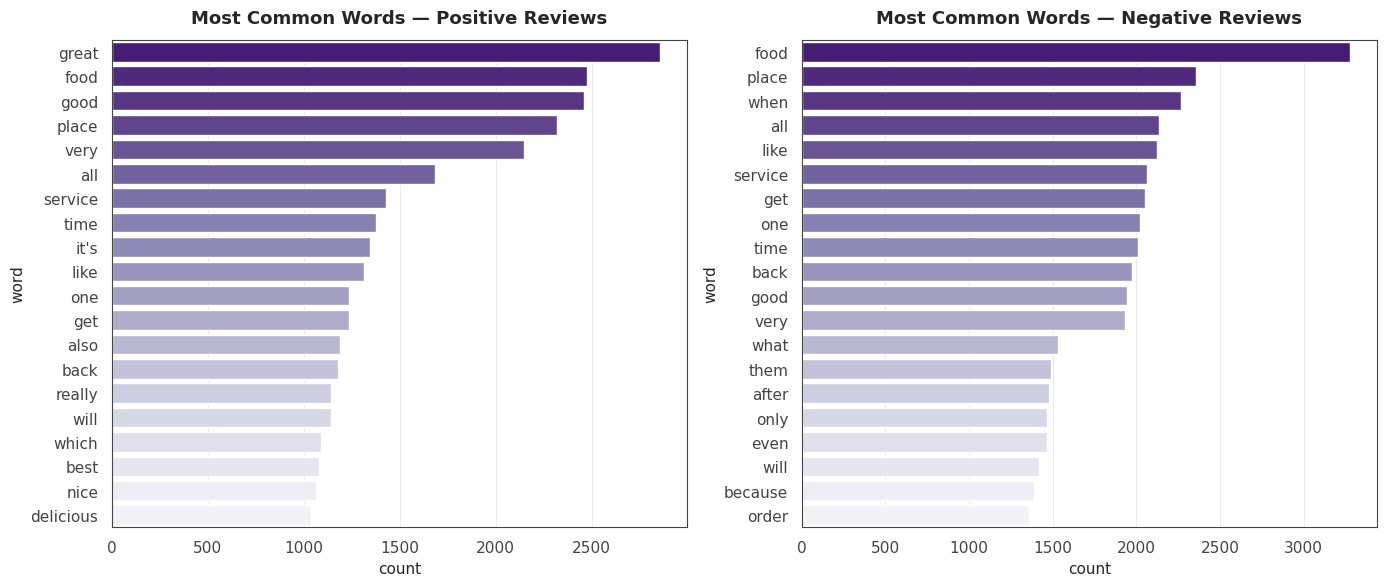

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
sns.barplot(
    data=top_positive,
    x="count",
    y="word",
    hue="word",
    palette=purple_sequential(len(top_positive), reverse=True),
    legend=False,
    ax=axes[0],
)
axes[0].set_title("Most Common Words — Positive Reviews")
sns.barplot(
    data=top_negative,
    x="count",
    y="word",
    hue="word",
    palette=purple_sequential(len(top_negative), reverse=True),
    legend=False,
    ax=axes[1],
)
axes[1].set_title("Most Common Words — Negative Reviews")
plt.tight_layout()
plt.savefig("../reports/eda_top_words.png", dpi=150)
plt.show()

## Write EDA summary to `reports/eda_summary.md`

This summary is referenced from the ML Design Document.

In [26]:
from pathlib import Path

report_dir = Path("../reports")
report_dir.mkdir(parents=True, exist_ok=True)

positive_count = int(sentiment_df.loc[sentiment_df["sentiment"] == "positive", "review_count"].iloc[0])
negative_count = int(sentiment_df.loc[sentiment_df["sentiment"] == "negative", "review_count"].iloc[0])

summary = f"""# EDA Summary

## Dataset

- Source table: `{table}` (Athena, Parquet-backed)
- Total reviews: {total_reviews:,}
- Reviews after removing 3-star neutral class: {positive_count + negative_count:,}

## Class Balance

- Positive (stars >= 4): {positive_count:,}
- Negative (stars <= 2): {negative_count:,}
- Positive share: {positive_count / max(positive_count + negative_count, 1):.2%}
- Negative share: {negative_count / max(positive_count + negative_count, 1):.2%}

## Review Length (10% sample)

- Average characters per review: {length_df['review_char_length'].mean():.1f}
- Median characters per review: {length_df['review_char_length'].median():.1f}
- 95th percentile: {length_df['review_char_length'].quantile(0.95):.1f}

## Data Quality

- Missing review text: {int(missing_df['missing_text'].iloc[0]):,}
- Missing star rating: {int(missing_df['missing_stars'].iloc[0]):,}

## Charts

- `reports/eda_star_distribution.png`
- `reports/eda_class_balance.png`
- `reports/eda_review_length.png`
- `reports/eda_top_words.png`
"""
(report_dir / "eda_summary.md").write_text(summary, encoding="utf-8")
print("Wrote", report_dir / "eda_summary.md")

Wrote ../reports/eda_summary.md


## Done

Continue to `03_feature_engineering_feature_store.ipynb` to engineer features and ingest them into the SageMaker Feature Store with the 40/10/10/40 split.